In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

np.set_printoptions(precision=10, suppress=True)

# ==================================================
# Load data
# =================================================

N = 100
emax = 1.2e-3
nfield = 21
L_list = [300]

all_data = []

for L in L_list:

    numerical_data = np.loadtxt(
        f"numerical_splitting_N{N}_L{L_list[0]}_emax{emax*1e4:.2f}_y.dat",
        skiprows=1
    )

    perturbative_data = np.loadtxt(
        f"Pymablock_Y_emax_{emax*1e4:.2f}_N{N}_L{L_list[0]}.dat",
        skiprows=1
    )

    # ==================================================
    # Relative error
    # ==================================================

    denom = np.abs(numerical_data[:, 4])

    relative_error = np.full_like(denom, np.nan, dtype=float)

    nonzero_gap = denom != 0

    relative_error[nonzero_gap] = (
        np.abs(
            numerical_data[nonzero_gap, 4]
            - perturbative_data[nonzero_gap, 3]
        )
        / denom[nonzero_gap]
    ) * 100

    # ==================================================
    # Build data array
    # ==================================================

    data = np.column_stack((
        np.full(len(numerical_data), L),   # L  
        numerical_data[:, 0],              # kx
        numerical_data[:, 1] ,        # Efield
        numerical_data[:, 2],              # E0
        numerical_data[:, 3],              # E1
        numerical_data[:, 4],              # numerical gap
        perturbative_data[:, 3],           # perturbative gap
        relative_error                     # relative error
    ))

    # ==================================================
    # Remove unwanted rows
    # ==================================================

    data = data[
        (data[:, 1] != 0) &
        (data[:, 2] != 0)
    ]

    data = data[np.isfinite(data[:, 7])]

    all_data.append(data)

# ==================================================
# Combine all L values together
# ==================================================

combined_data = np.vstack(all_data)

# ==================================================
# Save combined file
# ==================================================

np.savetxt(
    "gap_comparison_data_y.dat",
    combined_data,
    header=(
        "L kx Efield  E0 E1 numerical_gap perturbative_gap relative_error_percent"
    ),
    fmt=(
        "%5d "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.4f"
    )
)

print("Combined data file saved successfully.")

Combined data file saved successfully.


8e-05


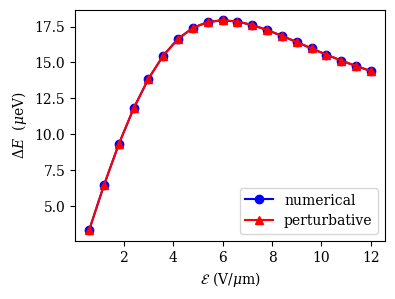

In [10]:
full_data = np.loadtxt("gap_comparison_data_y.dat")[: nfield-1]
kval = full_data[:,1]
Efield = full_data[:,2]
numsplit = full_data[:,5]
persplit = full_data[:,6]
print(kval[0])
plt.figure(figsize=(4,3))
plt.plot(Efield, numsplit, '-o', color = "blue", label = "numerical")
plt.plot(Efield, persplit, '-^', color = "red", label = "perturbative")
plt.xlabel(r"$\mathcal{E}$ (V/$\mu$m)")
plt.ylabel(r"$\Delta E$  ($\mu$eV)")
plt.legend(loc = "lower right")
plt.show()

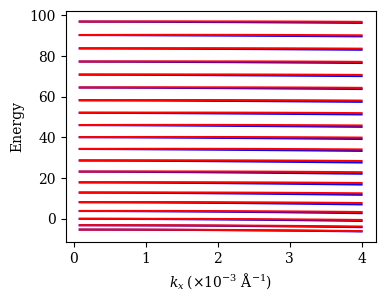

In [11]:

step = nfield - 1
# step = 20

full_data = np.loadtxt("gap_comparison_data_y.dat")

plt.figure(figsize=(4, 3))

for offset in range(step):
    group = full_data[offset::step]
    kx = group[:, 1] * 1e3
    band1 = group[:, 3]
    band2 = group[:, 4]

    plt.plot(kx, band1, color='blue')
    plt.plot(kx, band2, color='red')
    

plt.xlabel(r"$k_x\;(\times 10^{-3}\ \mathrm{\AA}^{-1})$")
plt.ylabel("Energy")
# plt.legend(loc='best')
plt.show()

Sizes: [300.]
kx range: 0.08 to 4.0
Electric-field range: 0.6 to 12.0


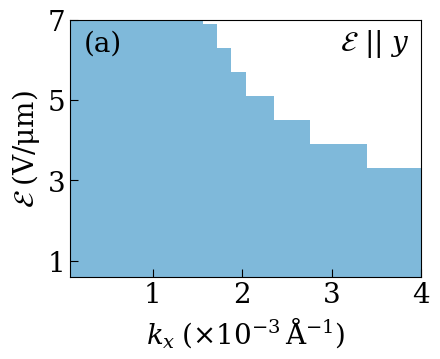

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==================================================
# Load data
# ==================================================

combined_data = np.loadtxt("gap_comparison_data_y.dat")

# Columns:
# 0: L
# 1: kx
# 2: Efield
# 3: E0
# 4: E1
# 5: numerical_gap
# 6: perturbative_gap
# 7: relative_error_percent

# ==================================================
# Plot settings
# ==================================================

plt.rcParams.update({
    "figure.figsize": [4.5, 3.7],
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif"
})

# ==================================================
# Extract columns
# ==================================================

size_all = combined_data[:, 0]

# Convert kx from Å^{-1} to 10^{-3} Å^{-1}
kx_all = combined_data[:, 1] * 1e3

Efield_all = combined_data[:, 2]
relerr_all = combined_data[:, 7]

sizes = np.sort(np.unique(size_all))
kx_vals = np.sort(np.unique(kx_all))
E_vals = np.sort(np.unique(Efield_all))

Nx = len(kx_vals)
NE = len(E_vals)

print("Sizes:", sizes)
print("kx range:", kx_vals.min(), "to", kx_vals.max())
print("Electric-field range:", E_vals.min(), "to", E_vals.max())

# ==================================================
# Relative-error threshold
# ==================================================

# relative_error_percent is already given in percent
threshold = 5.0       # 5%
# threshold = 0.1     # use this for 0.1%

# ==================================================
# Construct cumulative validity map
# ==================================================

# V = 0: no size satisfies the error threshold
# V = 1, 2, ...: corresponding size is valid

V = np.zeros((NE, Nx), dtype=int)

for level, size0 in enumerate(sizes, start=1):

    mask = np.isclose(size_all, size0)

    current_kx = kx_all[mask]
    current_E = Efield_all[mask]
    current_error = relerr_all[mask]

    # Build the grid explicitly, without relying on row ordering
    Z = np.full((NE, Nx), np.nan)

    kx_indices = np.searchsorted(kx_vals, current_kx)
    E_indices = np.searchsorted(E_vals, current_E)

    Z[E_indices, kx_indices] = current_error

    valid = np.isfinite(Z) & (Z < threshold)

    # Since sizes are sorted, a larger valid size overwrites
    # a smaller valid size.
    V[valid] = level

# ==================================================
# Discrete colormap
# ==================================================

number_of_sizes = len(sizes)

# White for invalid region
invalid_color = np.array([[1.0, 1.0, 1.0, 1.0]])

# Blue shades for valid sizes
valid_colors = plt.cm.Blues(
    np.linspace(0.45, 0.90, number_of_sizes)
)

colors = np.vstack([invalid_color, valid_colors])
cmap = ListedColormap(colors)

# Integer-centered discrete color boundaries
boundaries = np.arange(
    -0.5,
    number_of_sizes + 1.5,
    1
)

norm = BoundaryNorm(boundaries, cmap.N)

# ==================================================
# Plot
# ==================================================

fig, ax = plt.subplots()

mesh = ax.pcolormesh(
    kx_vals,
    E_vals,
    V,
    cmap=cmap,
    norm=norm,
    shading="nearest"
)

# # Draw boundary of the validity region
# if np.any(V > 0) and np.any(V == 0):
#     ax.contour(
#         kx_vals,
#         E_vals,
#         V,
#         levels=[0.5],
#         colors="black",
#         linewidths=1.2
#     )

# # ==================================================
# # Colorbar
# # ==================================================

# cbar = fig.colorbar(
#     mesh,
#     ax=ax,
#     ticks=np.arange(number_of_sizes + 1),
#     pad=0.03
# )

# # Assuming L is stored in Å; convert it to nm
# colorbar_labels = ["Invalid"] + [
#     rf"$L={size/10:g}\,\mathrm{{nm}}$"
#     for size in sizes
# ]

# cbar.ax.set_yticklabels(colorbar_labels)
# cbar.ax.tick_params(labelsize=11)

# ==================================================
# Labels and annotations
# ==================================================

ax.text(
    0.77,
    0.88,
    r"$\mathcal{E}$ || $y$",
    transform=ax.transAxes,
    fontsize=20
)


ax.set_xlabel(
    r"$k_x\;(\times 10^{-3}\,\mathrm{\AA}^{-1})$",
    fontsize=20
)

ax.set_ylabel(
    r"$\mathcal{E}\;(\mathrm{V/\mu m})$",
    fontsize=20
)

ax.tick_params(
    direction="in",
    top=False,
    right=False,
    length=6,
    labelsize=20
)

ax.set_xlim(kx_vals.min(), kx_vals.max())
ax.set_ylim(E_vals.min(), 7)

ax.set_xticks([1, 2, 3, 4])
ax.set_yticks([1, 3, 5, 7])
ax.text(
    0.04,
    0.88,
    "(a)",
    transform=ax.transAxes,
    fontsize=20
)

plt.tight_layout()

plt.savefig("validity_zone_Ey.png", dpi=300, bbox_inches="tight")
plt.savefig("validity_zone_Ey.pdf", bbox_inches="tight")
plt.savefig("validity_zone_Ey.svg", bbox_inches="tight")

plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

np.set_printoptions(precision=10, suppress=True)

# ==================================================
# Load data
# =================================================

N = 50
emax = 1.0e-3
nfield = 41
L_list = [300]

all_data = []

for L in L_list:

    numerical_data = np.loadtxt(
        f"numerical_splitting_N{N}_L{L_list[0]}_emax{emax*1e4:.2f}_z.dat",
        skiprows=1
    )

    perturbative_data = np.loadtxt(
        f"Pymablock_Z_emax_{emax*1e4:.2f}_N{N}_L{L_list[0]}.dat",
        skiprows=1
    )

    # ==================================================
    # Relative error
    # ==================================================

    denom = np.abs(numerical_data[:, 4])

    relative_error = np.full_like(denom, np.nan, dtype=float)

    nonzero_gap = denom != 0

    relative_error[nonzero_gap] = (
        np.abs(
            numerical_data[nonzero_gap, 4]
            - perturbative_data[nonzero_gap, 3]
        )
        / denom[nonzero_gap]
    ) * 100

    # ==================================================
    # Build data array
    # ==================================================

    data = np.column_stack((
        np.full(len(numerical_data), L),   # L  
        numerical_data[:, 0],              # kx
        numerical_data[:, 1] ,        # Efield
        numerical_data[:, 2],              # E0
        numerical_data[:, 3],              # E1
        numerical_data[:, 4],              # numerical gap
        perturbative_data[:, 3],           # perturbative gap
        relative_error                     # relative error
    ))

    # ==================================================
    # Remove unwanted rows
    # ==================================================

    data = data[
        (data[:, 1] != 0) &
        (data[:, 2] != 0)
    ]

    data = data[np.isfinite(data[:, 7])]

    all_data.append(data)

# ==================================================
# Combine all L values together
# ==================================================

combined_data = np.vstack(all_data)

# ==================================================
# Save combined file
# ==================================================

np.savetxt(
    "gap_comparison_data_z.dat",
    combined_data,
    header=(
        "L kx Efield  E0 E1 numerical_gap perturbative_gap relative_error_percent"
    ),
    fmt=(
        "%5d "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.6f "
        "%12.4f"
    )
)

print("Combined data file saved successfully.")

Combined data file saved successfully.


4e-05


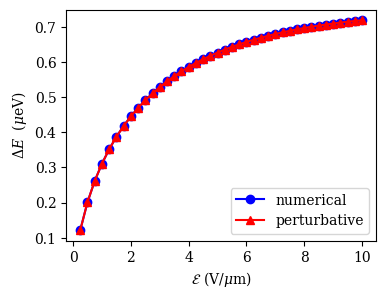

In [14]:
full_data = np.loadtxt("gap_comparison_data_z.dat")[: nfield-1]
kval = full_data[:,1]
Efield = full_data[:,2]
numsplit = full_data[:,5]
persplit = full_data[:,6]
print(kval[0])
plt.figure(figsize=(4,3))
plt.plot(Efield, numsplit, '-o', color = "blue", label = "numerical")
plt.plot(Efield, persplit, '-^', color = "red", label = "perturbative")
plt.xlabel(r"$\mathcal{E}$ (V/$\mu$m)")
plt.ylabel(r"$\Delta E$  ($\mu$eV)")
plt.legend(loc = "lower right")
plt.show()

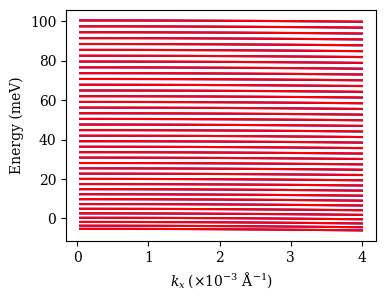

In [15]:

step = nfield - 1

full_data = np.loadtxt("gap_comparison_data_z.dat")

plt.figure(figsize=(4, 3))

for offset in range(step):
    group = full_data[offset::step]
    kx = group[:, 1] * 1e3
    band1 = group[:, 3]
    band2 = group[:, 4]

    plt.plot(kx, band1, color='blue')
    plt.plot(kx, band2, color='red')
    

plt.xlabel(r"$k_x\;(\times 10^{-3}\ \mathrm{\AA}^{-1})$")
plt.ylabel("Energy (meV)")
# plt.legend(loc='best')
plt.show()

Sizes: [300.]
kx range: 0.04 to 4.0
Electric-field range: 0.25 to 10.0


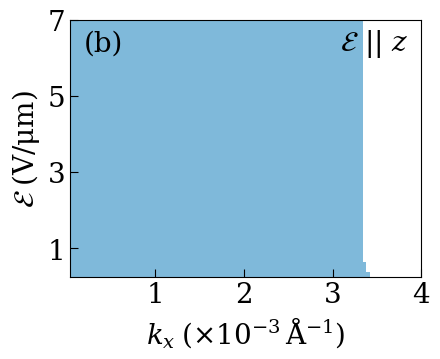

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ==================================================
# Load data
# ==================================================

combined_data = np.loadtxt("gap_comparison_data_z.dat")

# Columns:
# 0: L
# 1: kx
# 2: Efield
# 3: E0
# 4: E1
# 5: numerical_gap
# 6: perturbative_gap
# 7: relative_error_percent

# ==================================================
# Plot settings
# ==================================================

plt.rcParams.update({
    "figure.figsize": [4.5, 3.7],
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif"
})

# ==================================================
# Extract columns
# ==================================================

size_all = combined_data[:, 0]

# Convert kx from Å^{-1} to 10^{-3} Å^{-1}
kx_all = combined_data[:, 1] * 1e3

Efield_all = combined_data[:, 2]
relerr_all = combined_data[:, 7]

sizes = np.sort(np.unique(size_all))
kx_vals = np.sort(np.unique(kx_all))
E_vals = np.sort(np.unique(Efield_all))

Nx = len(kx_vals)
NE = len(E_vals)

print("Sizes:", sizes)
print("kx range:", kx_vals.min(), "to", kx_vals.max())
print("Electric-field range:", E_vals.min(), "to", E_vals.max())

# ==================================================
# Relative-error threshold
# ==================================================

# relative_error_percent is already given in percent
threshold = 4.9584      # 5%
# threshold = 0.1     # use this for 0.1%

# ==================================================
# Construct cumulative validity map
# ==================================================

# V = 0: no size satisfies the error threshold
# V = 1, 2, ...: corresponding size is valid

V = np.zeros((NE, Nx), dtype=int)

for level, size0 in enumerate(sizes, start=1):

    mask = np.isclose(size_all, size0)

    current_kx = kx_all[mask]
    current_E = Efield_all[mask]
    current_error = relerr_all[mask]

    # Build the grid explicitly, without relying on row ordering
    Z = np.full((NE, Nx), np.nan)

    kx_indices = np.searchsorted(kx_vals, current_kx)
    E_indices = np.searchsorted(E_vals, current_E)

    Z[E_indices, kx_indices] = current_error

    valid = np.isfinite(Z) & (Z < threshold)

    # Since sizes are sorted, a larger valid size overwrites
    # a smaller valid size.
    V[valid] = level

# ==================================================
# Discrete colormap
# ==================================================

number_of_sizes = len(sizes)

# White for invalid region
invalid_color = np.array([[1.0, 1.0, 1.0, 1.0]])

# Blue shades for valid sizes
valid_colors = plt.cm.Blues(
    np.linspace(0.45, 0.90, number_of_sizes)
)

colors = np.vstack([invalid_color, valid_colors])
cmap = ListedColormap(colors)

# Integer-centered discrete color boundaries
boundaries = np.arange(
    -0.5,
    number_of_sizes + 1.5,
    1
)

norm = BoundaryNorm(boundaries, cmap.N)

# ==================================================
# Plot
# ==================================================

fig, ax = plt.subplots()

mesh = ax.pcolormesh(
    kx_vals,
    E_vals,
    V,
    cmap=cmap,
    norm=norm,
    shading="nearest"
)

# # Draw boundary of the validity region
# if np.any(V > 0) and np.any(V == 0):
#     ax.contour(
#         kx_vals,
#         E_vals,
#         V,
#         levels=[0.5],
#         colors="black",
#         linewidths=1.2
#     )

# # ==================================================
# # Colorbar
# # ==================================================

# cbar = fig.colorbar(
#     mesh,
#     ax=ax,
#     ticks=np.arange(number_of_sizes + 1),
#     pad=0.03
# )

# # Assuming L is stored in Å; convert it to nm
# colorbar_labels = ["Invalid"] + [
#     rf"$L={size/10:g}\,\mathrm{{nm}}$"
#     for size in sizes
# ]

# cbar.ax.set_yticklabels(colorbar_labels)
# cbar.ax.tick_params(labelsize=11)

# ==================================================
# Labels and annotations
# ==================================================

ax.text(
    0.77,
    0.88,
    r"$\mathcal{E}$ || $z$",
    transform=ax.transAxes,
    fontsize=20
)

ax.set_xlabel(
    r"$k_x\;(\times 10^{-3}\,\mathrm{\AA}^{-1})$",
    fontsize=20
)

ax.set_ylabel(
    r"$\mathcal{E}\;(\mathrm{V/\mu m})$",
    fontsize=20
)

ax.tick_params(
    direction="in",
    top=False,
    right=False,
    length=6,
    labelsize=20
)

ax.set_xlim(kx_vals.min(), kx_vals.max())
ax.set_ylim(E_vals.min(), 7)

ax.set_xticks([1, 2, 3, 4])
ax.set_yticks([1, 3, 5, 7])
ax.text(
    0.04,
    0.88,
    "(b)",
    transform=ax.transAxes,
    fontsize=20
)

plt.tight_layout()

plt.savefig("validity_zone_Ez.png", dpi=300, bbox_inches="tight")
plt.savefig("validity_zone_Ez.pdf", bbox_inches="tight")
plt.savefig("validity_zone_Ez.svg", bbox_inches="tight")

plt.show()